# Name:Pratiksha Dhondiram Khot
# Rollno:CO2033

# House Price Prediction using Machine Learning

## 1.Problem Statement

#### The objective of this project is to build a machine learning model that predicts house prices based on various features such as the number of bedrooms, bathrooms, living area, lot size, location, and other property characteristics.

## 2.Dataset Information

#### The dataset contains information about residential properties and their selling prices.
#### -Dataset Name: House Price Prediction Dataset
#### -Targer Variable: House Price (Sale price)
#### -Problem Type: Regression
#### -Missing Values: Numerical and categorical

## 3.Importing Library

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("Importing Library")

Importing Library


## 4.Data Loading

In [2]:
df = pd.read_csv("House Price Prediction Dataset.csv")
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [3]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [5]:
df.shape

(2000, 10)

In [6]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [7]:
df.dtypes

Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

## 5.Cleaning dataset

In [8]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [11]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


## 6.Exploratory Data Analysis (EDA)

### 1.Histogram

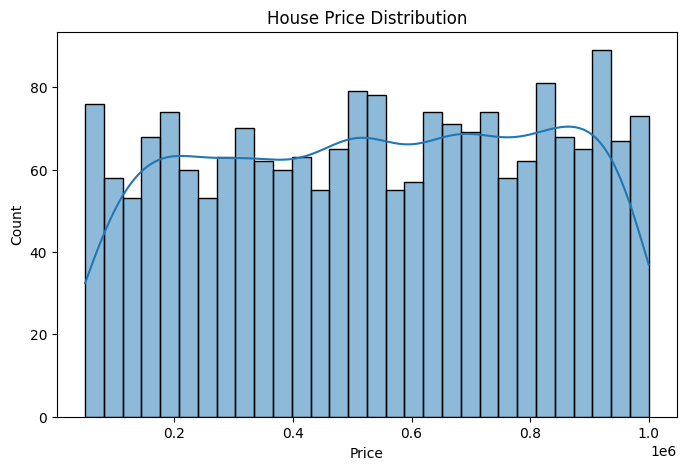

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("House Price Distribution")
plt.show()

### 2.Correlation Heatmap

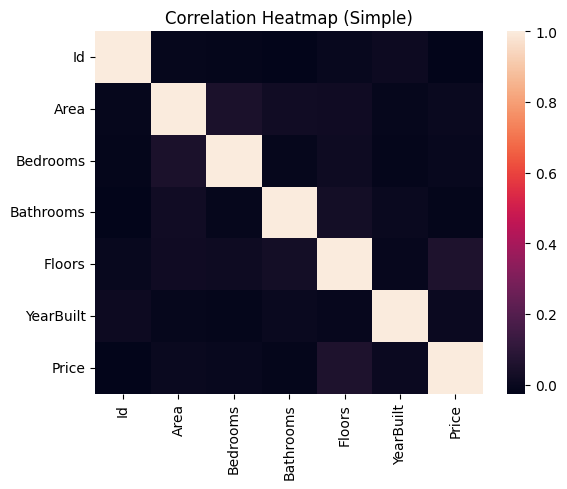

In [13]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(6,5)) 
sns.heatmap(corr)
plt.title('Correlation Heatmap (Simple)') 
plt.tight_layout()
plt.show()

### 3.Box plot

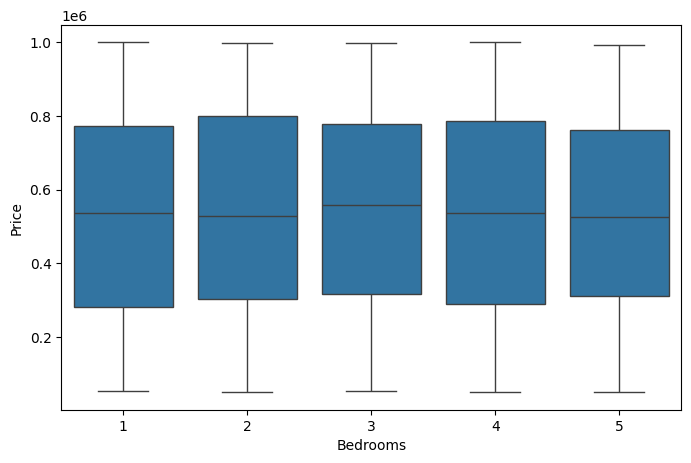

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Bedrooms', y='Price', data=df)
plt.show()

### 4.Scatter plot

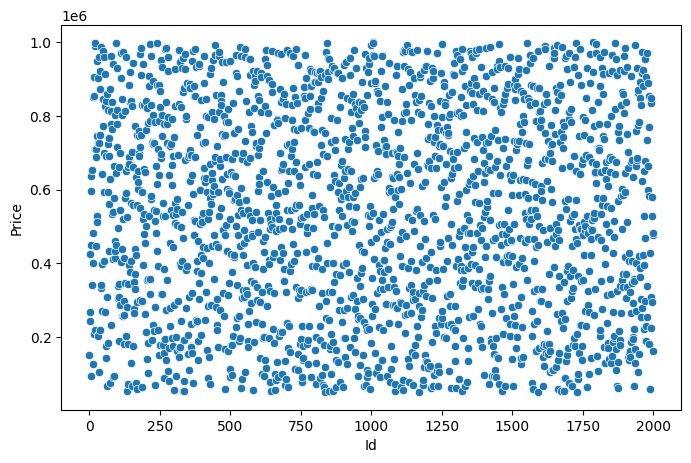

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Id', y='Price', data=df)
plt.show()

### 5.Pair plot

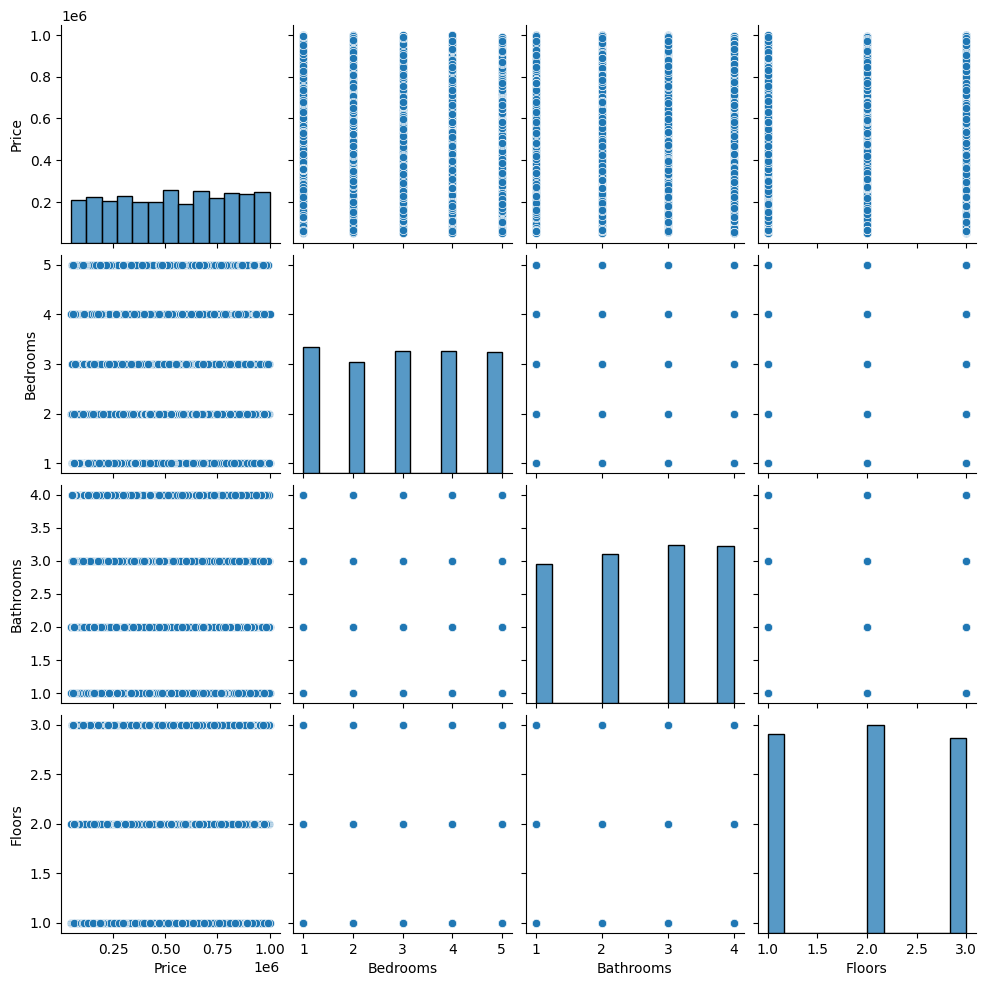

In [16]:
sns.pairplot(df[['Price','Bedrooms','Bathrooms','Floors']])
plt.show()

### 6.Joint plot

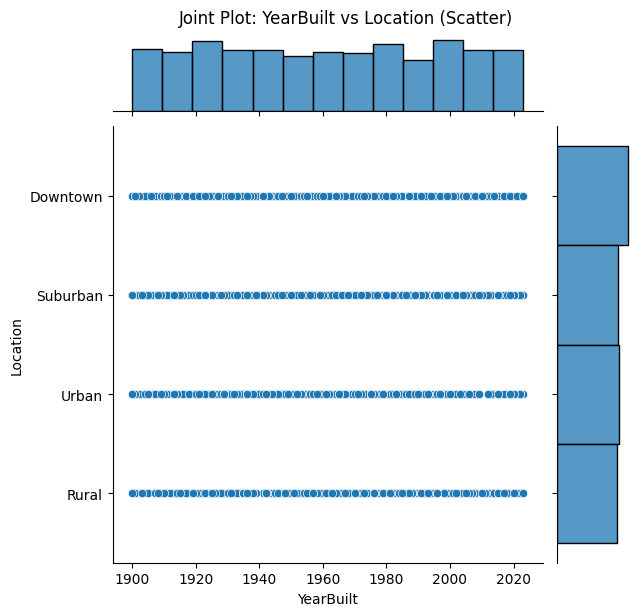

In [17]:
sns.jointplot(data=df, x='YearBuilt', y='Location', height=6) 
plt.suptitle('Joint Plot: YearBuilt vs Location (Scatter)', y=1.02) 
plt.show()

### 7.Relplot

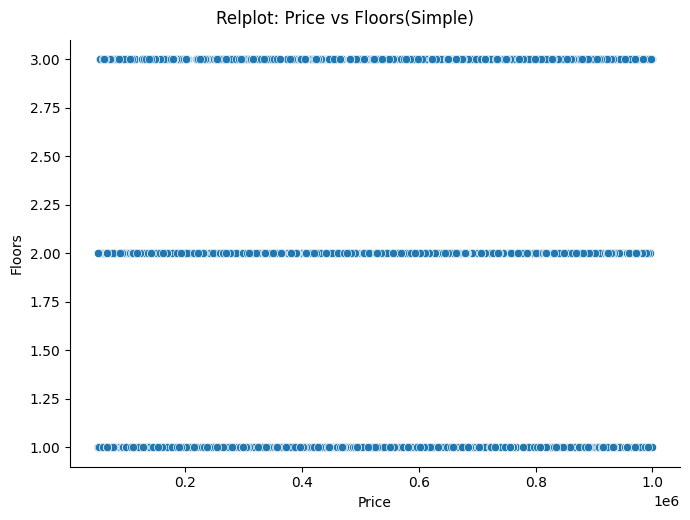

In [18]:
sns.relplot(data=df, x='Price', y='Floors', height=5, aspect=1.4) 
plt.suptitle('Relplot: Price vs Floors(Simple)', y=1.03) 
plt.show()

### 8.Line plot

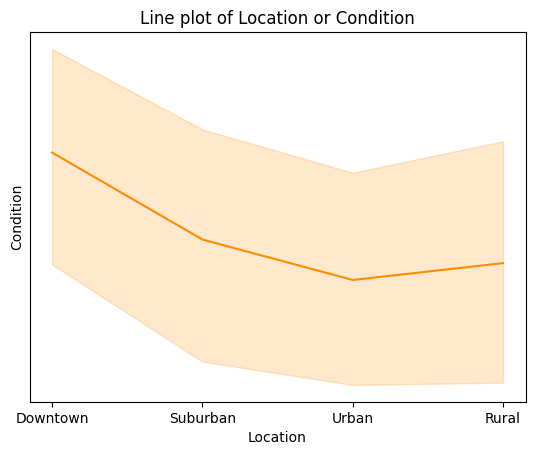

In [19]:
sns.lineplot(
    data=df,
    x="Location",
    y="Condition",
    color='darkorange'
)

plt.title("Line plot of Location or Condition")
plt.xlabel("Location")                     
plt.ylabel("Condition")
plt.show()

### 9.Violin plot

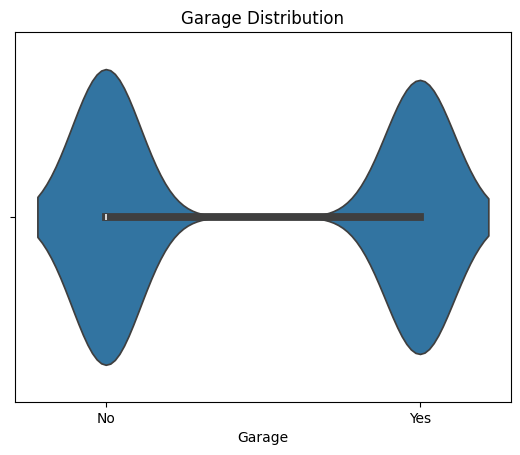

In [20]:
sns.violinplot(x='Garage', data=df)
plt.title("Garage Distribution")
plt.show()

### 10.Count plot

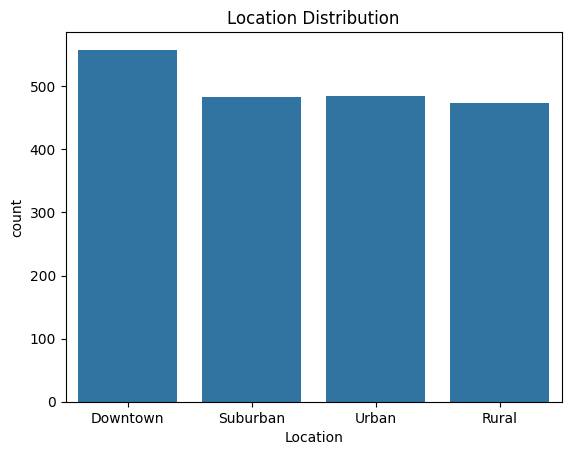

In [21]:
sns.countplot(x='Location', data=df)
plt.title("Location Distribution")
plt.show()

## 7.Feature Engineering

In [22]:
# Separate Features and Target X,y
X = df.drop("Price", axis=1)
y = df["Price"]

In [23]:
print(X.shape)
print(y.shape)

(2000, 9)
(2000,)


In [24]:
# One-Hot Encoding 
X = pd.get_dummies(X, drop_first=True)

### Train-Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 13)
(400, 13)
(1600,)
(400,)


## 8.Model Building

In [28]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-6892.13, -629.81, 76. ,...,-5485.86, 1916.41, 1107.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.362e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[47.49,46.48,45.54,...,38.25,24.19,22.95]"


 #### The Linear Regression model was trained using the training dataset with the fit() method.

In [29]:
y_pred = lr.predict(X_test)

In [30]:
y_pred

array([511317.73109931, 557359.55652936, 482838.34523391, 540695.6411198 ,
       549288.50244107, 518144.16928401, 523405.40235976, 568346.51627797,
       556990.3977267 , 573402.71846042, 560327.02526869, 580125.07750594,
       509628.89913772, 532492.70848044, 509721.56444397, 572094.84475122,
       536987.54980342, 567213.27046174, 571135.70064566, 512073.55283631,
       539312.23348974, 511844.49461755, 508598.43117479, 589678.62607714,
       559483.71580206, 540987.05449051, 522708.73013649, 534204.67811389,
       520198.55289369, 500920.60216369, 475555.72605338, 533069.83976321,
       564818.74920608, 567197.08659151, 504221.60797606, 510451.11954577,
       559173.27166252, 583163.79071258, 532087.00828381, 512605.87316523,
       499271.26212725, 530223.34803808, 547450.7379217 , 543281.28975282,
       533429.88712312, 575342.14120786, 557923.59595814, 538457.64588905,
       542099.1954386 , 521037.26607699, 508733.44694034, 558684.27065773,
       561335.50693823, 5

In [31]:
#Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [32]:
rf_pred = rf.predict(X_test)

In [33]:
rf_pred

array([625428.24, 496642.11, 464175.24, 565412.99, 582864.91, 549428.32,
       452498.66, 536445.  , 492396.77, 621972.65, 515410.74, 665403.82,
       507336.87, 517927.21, 509866.49, 542898.79, 684155.03, 530197.08,
       634306.15, 442424.67, 524937.83, 472750.97, 493245.5 , 617986.7 ,
       471503.7 , 624984.56, 486231.28, 481213.75, 491627.73, 616132.58,
       520106.54, 519990.47, 574528.11, 546971.68, 365291.71, 383286.14,
       599296.45, 553559.81, 549326.51, 478727.31, 513196.47, 521314.61,
       570742.74, 482970.88, 418484.14, 572233.96, 503912.63, 492946.52,
       480305.92, 504418.45, 535427.85, 521155.5 , 598598.7 , 473555.6 ,
       588161.  , 549716.05, 583466.04, 463589.45, 506729.82, 467666.08,
       593646.83, 573641.03, 570057.36, 473686.1 , 435798.15, 461291.75,
       548634.78, 468946.13, 526884.57, 538574.84, 531035.4 , 649809.41,
       540169.82, 477313.68, 478470.65, 656772.15, 645760.74, 529657.89,
       525520.12, 516904.15, 542672.95, 514299.54, 

## 9.Model Evaluation

In [34]:
#Linear Regression
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 242867.44926338628
RMSE: 279785.21069002635
R2 Score: -0.006181784611834162


In [35]:
#Random Forest
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE: 249884.79142500003
RMSE: 288756.71426025714
R2 Score: -0.0717441588346377


## 10.Conclusion

#### The dataset was successfully cleaned and preprocessed. Exploratory Data Analysis identified important relationships between house price and features such as living area, grade, and number of bathrooms. Feature engineering included encoding categorical variables and scaling numerical features. 
#### Two machine learning models were trained:Linear Regression, Random Forest Regressor. Model performance was evaluated using MAE, RMSE, and R² Score. The Random Forest Regressor generally performs better than Linear Regression because it captures non-linear relationships and interactions between features, resulting in higher prediction accuracy.